# Securing ML Model APIs — Authentication, Rate Limiting, Input Validation

A deployed ML model is only as secure as the API in front of it. This notebook covers four concrete security layers every ML API should have:
1. API key authentication
2. JWT token authentication
3. Rate limiting
4. Input validation and sanitization

All code runs fully locally — no cloud credentials required.

## 🔗 Where this fits

**Builds on:** Course 06 (AIAT 116) — Unit 3, lesson 05 "05. Secure AI Development" — the threats you catalogued there (unauthorised access, adversarial and poisoned input) become concrete middleware here: API keys, JWTs, rate limits and request validation.


## 📰 ShellTorch: thousands of model servers open to anyone who found them

In **October 2023** the Oligo security team disclosed a chain of vulnerabilities in **TorchServe**, PyTorch's official model server, which they named *ShellTorch*. Two were near-maximum severity: **CVE-2023-43654** (CVSS 9.8), where the allow-list for fetching model configuration from a remote URL accepted **every** domain, turning it into a server-side request forgery that led to remote code execution; and **CVE-2022-1471** (CVSS 9.9), unsafe Java deserialization via a vulnerable SnakeYAML version. What turned two bugs into thousands of exposed servers was a configuration default: TorchServe's **management API — the interface that loads and unloads models — bound to every network interface rather than to localhost**, with no authentication. Researchers reported reaching TorchServe instances belonging to some of the largest organisations in the world. All versions up to 0.8.1 were affected; the fix was 0.8.2 plus setting `management_address` to `http://127.0.0.1:8081`.

Nobody in that story attacked a model. They attacked the **service around** the model — a default, an unauthenticated port, and an outdated dependency.

**What goes wrong without this lesson.** An ML endpoint is a normal web service that happens to run inference, and it inherits every normal web vulnerability: unauthenticated callers, abusive request volume, and malformed input. It also adds two of its own — predictions that may be commercially or medically sensitive, and inference that costs real money per call, which makes an unauthenticated endpoint a way for a stranger to spend your budget. Everything below is the minimum: who are you, how often may you ask, and is this input even a number.

## Learning Objectives

By the end of this notebook you will be able to:
1. Implement API key validation in FastAPI using a header dependency
2. Issue and validate JWT tokens and protect an endpoint that requires one
3. Build in-memory rate limiting to prevent API abuse
4. Write an input sanitization function and explain why it matters for ML APIs

## Setup

In [1]:
# WHAT: install the security toolkit — FastAPI, httpx, and python-jose for JWTs.
# WHY: every defense in this lesson (API keys, tokens, rate limits) is built and
# TESTED live, so the libraries must be present up front.
import subprocess, sys

packages = ['fastapi', 'httpx', 'python-jose[cryptography]']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True)
print('Dependencies installed: fastapi, httpx, python-jose')

Dependencies installed: fastapi, httpx, python-jose


## Section 1 — API Key Authentication

The simplest auth mechanism: the caller includes a secret key in a request header. The server validates it before processing the request.

**Authentication** = proving who you are.
**Authorization** = deciding what you are allowed to do.

An API key handles authentication. A role or permission system handles authorization.

In [2]:
# WHAT: protect a /predict endpoint with an API key checked by a FastAPI dependency.
# WHY: API keys are the simplest auth layer — note the two distinct failures:
# 401 when the key is MISSING vs 403 when it is present but WRONG.
import secrets
from fastapi import FastAPI, Depends, HTTPException, status
from fastapi.security import APIKeyHeader
from fastapi.testclient import TestClient

# In production: store this in an environment variable, not in code
VALID_API_KEYS = {
    'sk-student-key-001': 'student_alice',
    'sk-student-key-002': 'student_bob',
}

app_apikey = FastAPI(title='ML API with API Key Auth')
api_key_header = APIKeyHeader(name='X-API-Key', auto_error=False)

# The dependency runs before the endpoint: no valid key, no prediction.
def require_api_key(api_key: str = Depends(api_key_header)):
    """FastAPI dependency: validates the API key and returns the owner name."""
    if api_key is None:
        raise HTTPException(
            status_code=status.HTTP_401_UNAUTHORIZED,
            detail='Missing X-API-Key header',
        )
    if api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=status.HTTP_403_FORBIDDEN,
            detail='Invalid API key',
        )
    return VALID_API_KEYS[api_key]

@app_apikey.post('/predict')
def predict(caller: str = Depends(require_api_key)):
    return {'prediction': 'setosa', 'caller': caller}

# Test it
client = TestClient(app_apikey)

print('Test 1 — no API key:')
r = client.post('/predict')
print(f'  Status: {r.status_code}, Body: {r.json()}')

print('Test 2 — wrong API key:')
r = client.post('/predict', headers={'X-API-Key': 'wrong-key'})
print(f'  Status: {r.status_code}, Body: {r.json()}')

print('Test 3 — valid API key:')
r = client.post('/predict', headers={'X-API-Key': 'sk-student-key-001'})
print(f'  Status: {r.status_code}, Body: {r.json()}')

Test 1 — no API key:
  Status: 401, Body: {'detail': 'Missing X-API-Key header'}
Test 2 — wrong API key:
  Status: 403, Body: {'detail': 'Invalid API key'}
Test 3 — valid API key:
  Status: 200, Body: {'prediction': 'setosa', 'caller': 'student_alice'}


/Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


## Section 2 — JWT Token Authentication

JSON Web Tokens (JWT) are a more sophisticated auth mechanism. A JWT contains:
- **Header**: algorithm used to sign the token
- **Payload**: claims about the user (user ID, expiry, roles)
- **Signature**: proves the token was issued by the server and hasn't been tampered with

The format is: `base64(header).base64(payload).signature`

Common use: a `/login` endpoint issues a short-lived JWT (15 min to 1 hour). The client sends it on every subsequent request in the `Authorization: Bearer <token>` header.

In [3]:
# WHAT: build JWT helpers — issue a signed token, then validate and decode it.
# WHY: unlike API keys, JWTs carry claims (who, until when) and are verified by
# SIGNATURE, so the server does not need a lookup table of issued tokens.
from datetime import datetime, timedelta, timezone
from jose import jwt, JWTError
from fastapi import FastAPI, Depends, HTTPException, status
from fastapi.security import HTTPBearer, HTTPAuthorizationCredentials
from fastapi.testclient import TestClient
from pydantic import BaseModel

SECRET_KEY = 'aiat125-super-secret-replace-in-production'
ALGORITHM = 'HS256'
TOKEN_EXPIRE_MINUTES = 30

def create_access_token(subject: str) -> str:
    """Issue a JWT that expires in TOKEN_EXPIRE_MINUTES."""
    expire = datetime.now(timezone.utc) + timedelta(minutes=TOKEN_EXPIRE_MINUTES)
    payload = {'sub': subject, 'exp': expire}
    return jwt.encode(payload, SECRET_KEY, algorithm=ALGORITHM)

def decode_access_token(token: str) -> str:
    """Validate a JWT and return the subject claim."""
    try:
        payload = jwt.decode(token, SECRET_KEY, algorithms=[ALGORITHM])
        subject = payload.get('sub')
        if subject is None:
            raise ValueError('Token missing sub claim')
        return subject
    except JWTError as e:
        raise HTTPException(
            status_code=status.HTTP_401_UNAUTHORIZED,
            detail=f'Invalid token: {e}',
            headers={'WWW-Authenticate': 'Bearer'},
        )

# A JWT is three base64 parts: header.payload.signature — decode and look inside.
# Show the token structure
token = create_access_token('user123')
print(f'Issued JWT: {token[:60]}...')

# Decode and inspect
import base64, json
header_b64, payload_b64, sig = token.split('.')
# Pad base64 string
header_json = json.loads(base64.b64decode(header_b64 + '=='))
payload_json = json.loads(base64.b64decode(payload_b64 + '=='))
print(f'\nHeader  : {header_json}')
print(f'Payload : {payload_json}')
print(f'Expires : {datetime.fromtimestamp(payload_json["exp"], tz=timezone.utc).isoformat()}')

Issued JWT: eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJzdWIiOiJ1c2VyMTIzIiw...

Header  : {'alg': 'HS256', 'typ': 'JWT'}
Payload : {'sub': 'user123', 'exp': 1788033531}
Expires : 2026-08-29T19:58:51+00:00


In [4]:
# WHAT: wire the JWT flow into an API: /login issues tokens, /predict requires them.
# WHY: this is the standard two-step dance — exchange credentials for a token
# once, then present the token on every call; tampering breaks the signature.
app_jwt = FastAPI(title='ML API with JWT Auth')
bearer_scheme = HTTPBearer(auto_error=False)

class LoginRequest(BaseModel):
    username: str
    password: str

FAKE_USER_DB = {'alice': 'password123', 'bob': 'hunter2'}

@app_jwt.post('/login')
def login(body: LoginRequest):
    if FAKE_USER_DB.get(body.username) != body.password:
        raise HTTPException(status_code=401, detail='Bad credentials')
    token = create_access_token(subject=body.username)
    return {'access_token': token, 'token_type': 'bearer'}

def require_jwt(credentials: HTTPAuthorizationCredentials = Depends(bearer_scheme)):
    if credentials is None:
        raise HTTPException(status_code=401, detail='Missing Authorization header')
    return decode_access_token(credentials.credentials)

@app_jwt.post('/predict')
def protected_predict(user: str = Depends(require_jwt)):
    return {'prediction': 'versicolor', 'user': user}

# Four moments of the token lifecycle: issue, reject-missing, accept, reject-tampered.
# Test the full flow
client = TestClient(app_jwt)

print('Step 1 — login to get a token:')
r = client.post('/login', json={'username': 'alice', 'password': 'password123'})
print(f'  Status: {r.status_code}')
jwt_token = r.json()['access_token']
print(f'  Token (first 40 chars): {jwt_token[:40]}...')

print('\nStep 2 — call the protected endpoint without token:')
r = client.post('/predict')
print(f'  Status: {r.status_code}, Body: {r.json()}')

print('\nStep 3 — call with valid token:')
r = client.post('/predict', headers={'Authorization': f'Bearer {jwt_token}'})
print(f'  Status: {r.status_code}, Body: {r.json()}')

print('\nStep 4 — call with tampered token:')
bad_token = jwt_token[:-5] + 'XXXXX'
r = client.post('/predict', headers={'Authorization': f'Bearer {bad_token}'})
print(f'  Status: {r.status_code}, Body: {r.json()}')

Step 1 — login to get a token:
  Status: 200
  Token (first 40 chars): eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJ...

Step 2 — call the protected endpoint without token:
  Status: 401, Body: {'detail': 'Missing Authorization header'}

Step 3 — call with valid token:
  Status: 200, Body: {'prediction': 'versicolor', 'user': 'alice'}

Step 4 — call with tampered token:
  Status: 401, Body: {'detail': 'Invalid token: Signature verification failed.'}


## Section 3 — Rate Limiting

Rate limiting prevents a single client from flooding your API. Without it, one bad actor can cause your endpoint to hit its resource limits, degrading service for everyone else.

A simple approach: keep a dictionary of `{ip_address: [request_timestamps]}` and reject requests if the count in the last 60 seconds exceeds the limit.

In [5]:
# WHAT: implement a sliding-window rate limiter in ~15 lines of Python.
# WHY: without limits, one buggy or malicious client can starve everyone else —
# rate limiting is availability protection, per client, not just security.
import time
from collections import defaultdict
from functools import wraps

# In-memory rate limiter: {client_id: [timestamps of recent requests]}
request_log = defaultdict(list)

RATE_LIMIT = 5         # max requests per window
WINDOW_SECONDS = 10    # sliding window size

# Keep only timestamps inside the window, then check if the budget is spent.
def is_rate_limited(client_id: str) -> bool:
    """Return True if the client has exceeded the rate limit."""
    now = time.time()
    # Remove timestamps older than the window
    request_log[client_id] = [
        t for t in request_log[client_id]
        if now - t < WINDOW_SECONDS
    ]
    if len(request_log[client_id]) >= RATE_LIMIT:
        return True
    request_log[client_id].append(now)
    return False

# Requests 6-8 from the same IP should be rejected; a new IP starts fresh.
# Simulate requests from two clients
print(f'Rate limit: {RATE_LIMIT} requests per {WINDOW_SECONDS} seconds')
print()

for i in range(8):
    client_id = '192.168.1.1'
    limited = is_rate_limited(client_id)
    verdict = 'REJECTED (429 Too Many Requests)' if limited else 'ACCEPTED (200 OK)'
    print(f'Request {i+1:02d} from {client_id}: {verdict}')

print()
print('Different client (different IP, not rate-limited):')
for i in range(3):
    limited = is_rate_limited('10.0.0.5')
    verdict = 'REJECTED' if limited else 'ACCEPTED'
    print(f'  Request {i+1}: {verdict}')

Rate limit: 5 requests per 10 seconds

Request 01 from 192.168.1.1: ACCEPTED (200 OK)
Request 02 from 192.168.1.1: ACCEPTED (200 OK)
Request 03 from 192.168.1.1: ACCEPTED (200 OK)
Request 04 from 192.168.1.1: ACCEPTED (200 OK)
Request 05 from 192.168.1.1: ACCEPTED (200 OK)
Request 06 from 192.168.1.1: REJECTED (429 Too Many Requests)
Request 07 from 192.168.1.1: REJECTED (429 Too Many Requests)
Request 08 from 192.168.1.1: REJECTED (429 Too Many Requests)

Different client (different IP, not rate-limited):
  Request 1: ACCEPTED
  Request 2: ACCEPTED
  Request 3: ACCEPTED


In [6]:
# Integrate rate limiting into FastAPI as a dependency
from fastapi import FastAPI, Request
from fastapi.testclient import TestClient

request_log.clear()  # reset for this demo

app_rl = FastAPI(title='ML API with Rate Limiting')

# Same limiter as above, packaged as a dependency with a proper 429 + Retry-After.
def check_rate_limit(request: Request):
    """FastAPI dependency: raise 429 if client exceeds rate limit."""
    client_ip = request.client.host if request.client else 'testclient'
    if is_rate_limited(client_ip):
        raise HTTPException(
            status_code=status.HTTP_429_TOO_MANY_REQUESTS,
            detail=f'Rate limit exceeded: max {RATE_LIMIT} requests per {WINDOW_SECONDS}s',
            headers={'Retry-After': str(WINDOW_SECONDS)},
        )

@app_rl.post('/predict')
def predict_with_rl(_: None = Depends(check_rate_limit)):
    return {'prediction': 'virginica'}

client = TestClient(app_rl)
print(f'Sending 8 rapid requests (limit is {RATE_LIMIT}):')
for i in range(8):
    r = client.post('/predict')
    print(f'  Request {i+1}: HTTP {r.status_code}')

Sending 8 rapid requests (limit is 5):
  Request 1: HTTP 200
  Request 2: HTTP 200
  Request 3: HTTP 200
  Request 4: HTTP 200
  Request 5: HTTP 200
  Request 6: HTTP 429
  Request 7: HTTP 429
  Request 8: HTTP 429


### What the limiter does over time

Both cells above stopped at the same moment: five accepted, three rejected. But a rate limiter is not a gate that latches shut — it is a window that keeps moving, and the client gets served again without anyone intervening. The cell below replays the identical rule on an explicit clock (so the picture costs no wall-clock time) and draws it, next to what happens to that same rule the day you run more than one replica.

Rule: 5 requests per 10s sliding window



'in window' = accepted requests still inside the window after this decision

  t (s)  in window  verdict
    0.0          1  200 OK
    0.5          2  200 OK
    1.0          3  200 OK
    1.5          4  200 OK
    2.0          5  200 OK
    2.5          5  429 Too Many Requests
    3.0          5  429 Too Many Requests
    3.5          5  429 Too Many Requests
   11.0          3  200 OK
   12.0          2  200 OK
   13.0          3  200 OK
   14.0          4  200 OK

Accepted 9 / 12; rejected 3.


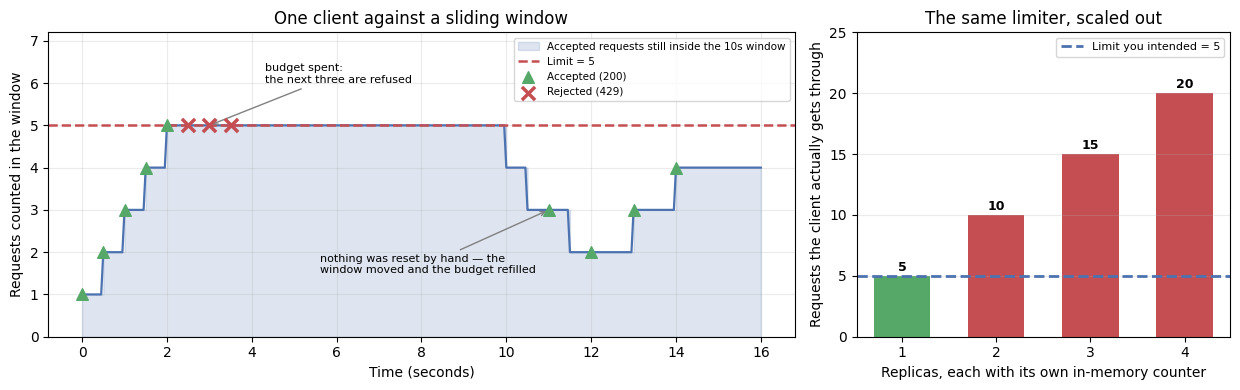

In [7]:
# WHAT: replay the SAME sliding-window rule on an explicit clock and draw it, then
# show what happens to that rule behind more than one replica.
# WHY: the printout above showed five ACCEPTED and three REJECTED and stopped
# there. The interesting part is what happens next — the window slides and the
# budget refills — and that is a picture, not a list.
import numpy as np
import matplotlib.pyplot as plt

# A stated arrival schedule (seconds), not measured traffic: a burst of eight
# requests, then a quiet gap, then four more once the window has moved on.
arrivals = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 11.0, 12.0, 13.0, 14.0]

def replay(schedule, limit=RATE_LIMIT, window=WINDOW_SECONDS):
    """Identical rule to is_rate_limited(), with `now` passed in instead of read from the clock."""
    seen, trace = [], []
    for now in schedule:
        seen = [t for t in seen if now - t < window]      # drop what left the window
        if len(seen) >= limit:
            trace.append((now, len(seen), False))          # 429
        else:
            seen.append(now)
            trace.append((now, len(seen), True))           # 200
    return trace

trace = replay(arrivals)
print(f"Rule: {RATE_LIMIT} requests per {WINDOW_SECONDS}s sliding window\n")
print("'in window' = accepted requests still inside the window after this decision\n")
print(f"{'t (s)':>7} {'in window':>10}  verdict")
for t, count, ok in trace:
    print(f"{t:7.1f} {count:10d}  {'200 OK' if ok else '429 Too Many Requests'}")
accepted = [(t, c) for t, c, ok in trace if ok]
rejected = [(t, c) for t, c, ok in trace if not ok]
print(f"\nAccepted {len(accepted)} / {len(arrivals)}; rejected {len(rejected)}.")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4), gridspec_kw={'width_ratios': [2, 1]})

ax = axes[0]
grid = np.arange(0, 16.01, 0.05)
occupancy = [sum(1 for t, _c, ok in trace if ok and 0 <= g - t < WINDOW_SECONDS) for g in grid]
ax.fill_between(grid, occupancy, step='post', color='#4C72B0', alpha=0.18,
                label=f'Accepted requests still inside the {WINDOW_SECONDS}s window')
ax.plot(grid, occupancy, color='#4C72B0', lw=1.6)
ax.axhline(RATE_LIMIT, color='#C44E52', ls='--', lw=1.8, label=f'Limit = {RATE_LIMIT}')
ax.scatter([t for t, _c in accepted], [c for _t, c in accepted], marker='^', s=70,
           color='#55A868', zorder=5, label='Accepted (200)')
ax.scatter([t for t, _c in rejected], [RATE_LIMIT] * len(rejected), marker='x', s=90,
           color='#C44E52', zorder=5, linewidths=2.5, label='Rejected (429)')
ax.annotate('budget spent:\nthe next three are refused',
            xy=(3.0, RATE_LIMIT), xytext=(4.3, 6.0), fontsize=8,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate('nothing was reset by hand — the\nwindow moved and the budget refilled',
            xy=(11.0, 3), xytext=(5.6, 1.5), fontsize=8,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Requests counted in the window')
ax.set_ylim(0, 7.2)
ax.set_title('One client against a sliding window')
ax.legend(fontsize=7.5, loc='upper right')
ax.grid(alpha=0.25)

ax = axes[1]
replicas = np.arange(1, 5)
effective = replicas * RATE_LIMIT
bars = ax.bar(replicas, effective, color=['#55A868'] + ['#C44E52'] * 3, width=0.6)
ax.axhline(RATE_LIMIT, color='#4C72B0', ls='--', lw=2,
           label=f'Limit you intended = {RATE_LIMIT}')
for r, e in zip(replicas, effective):
    ax.text(r, e + 0.4, str(e), ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(replicas)
ax.set_xlabel('Replicas, each with its own in-memory counter')
ax.set_ylabel('Requests the client actually gets through')
ax.set_ylim(0, effective.max() * 1.25)
ax.set_title('The same limiter, scaled out')
ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.show()


**🔍 Read the figure.** *Left panel:* the shaded area is how many accepted requests are still inside the 10-second window, and the red dashed line is the limit of 5. The first five arrivals climb the staircase; at `t=2.5s` the area touches the limit and the next three arrivals are the red crosses — refused with **429** while the counter stays at 5. Then follow the curve past `t=10s`: it steps down on its own as the earliest requests age out of the window, and the client is served again at `t=11s` with **no reset, no restart and no operator**. That self-healing is the property a sliding window buys you, and it is why the correct response to a 429 is `Retry-After`, not an escalation.

*Right panel:* the same rule, unchanged, behind more replicas. Each process keeps its own `request_log` dictionary, so a client whose requests land across 4 replicas gets **20** through a limit you wrote as **5**. The rule did not fail — it was never shared. That is the first bullet of "⚠️ Where this breaks" as a picture, and the reason production limiters live in Redis or in the API gateway.

## Section 4 — Input Sanitization

Even if a caller is authenticated, you must validate their input before passing it to the model. Reasons:

- **Crashes**: passing a string where a float is expected will throw a `ValueError` inside your model
- **Adversarial inputs**: extreme values or NaN can produce garbage predictions without crashing
- **Security**: malformed or extreme values are a common probing technique. Validating shape, dtype, and range blocks the easy abuse cases. (Note: sophisticated attacks such as model-inversion or membership-inference, which try to leak training data, need defenses *beyond* input validation — validation alone does not stop them.)

Always validate: shape, dtype, value range, and presence of NaN/Inf.

In [8]:
# WHAT: sanitize model input — dtype, shape, NaN/Inf, and physical value ranges.
# WHY: schema validation alone accepts sepal_length=99.0; range checks encode
# DOMAIN knowledge, the difference between valid JSON and valid data.
import numpy as np

# Feature constraints for the iris model
FEATURE_RANGES = {
    'sepal_length': (4.0, 8.0),
    'sepal_width':  (1.5, 5.0),
    'petal_length': (0.5, 7.5),
    'petal_width':  (0.0, 3.0),
}
FEATURE_NAMES = list(FEATURE_RANGES.keys())

# Four layers, cheapest first: convert, shape-check, finiteness, then ranges.
def sanitize_input(raw_features):
    """
    Validate and sanitize model input.
    Returns a clean numpy array or raises ValueError.
    """
    # 1. Convert to numpy array
    try:
        arr = np.array(raw_features, dtype=float)
    except (ValueError, TypeError) as e:
        raise ValueError(f'Cannot convert input to float array: {e}')

    # 2. Check shape
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    if arr.shape[1] != len(FEATURE_NAMES):
        raise ValueError(
            f'Expected {len(FEATURE_NAMES)} features, got {arr.shape[1]}'
        )

    # 3. Check for NaN or Infinity
    if not np.isfinite(arr).all():
        raise ValueError('Input contains NaN or Infinity values')

    # 4. Check value ranges
    for col_idx, (name, (low, high)) in enumerate(FEATURE_RANGES.items()):
        col = arr[:, col_idx]
        if np.any(col < low) or np.any(col > high):
            raise ValueError(
                f'{name} out of range [{low}, {high}]: got {col.tolist()}'
            )

    return arr

# Every malformed case must be BLOCKED with a message naming the exact problem.
# Test with various inputs
test_cases = [
    ([5.1, 3.5, 1.4, 0.2],          'Valid input'),
    ([5.1, 3.5, 1.4],               'Wrong number of features'),
    ([5.1, 3.5, float('nan'), 0.2], 'NaN value'),
    ([5.1, 3.5, float('inf'), 0.2], 'Infinity value'),
    ([99.0, 3.5, 1.4, 0.2],        'Extreme value (sepal_length=99)'),
    (['a', 3.5, 1.4, 0.2],         'String in numeric array'),
]

for features, description in test_cases:
    try:
        clean = sanitize_input(features)
        print(f'  PASS [{description}]: shape={clean.shape}')
    except ValueError as e:
        print(f'  BLOCKED [{description}]: {e}')

  PASS [Valid input]: shape=(1, 4)
  BLOCKED [Wrong number of features]: Expected 4 features, got 3
  BLOCKED [NaN value]: Input contains NaN or Infinity values
  BLOCKED [Infinity value]: Input contains NaN or Infinity values
  BLOCKED [Extreme value (sepal_length=99)]: sepal_length out of range [4.0, 8.0]: got [99.0]
  BLOCKED [String in numeric array]: Cannot convert input to float array: could not convert string to float: 'a'


## 💬 Discuss

Compare what the four layers actually produced. The API-key test printed a clean split — **401** for a missing header, **403** for a wrong key, **200** for a valid one. The JWT test rejected a tampered token with `Signature verification failed`. The rate limiter accepted five requests and returned **429** for the next three. And the input sanitizer blocked NaN, Infinity, a string, a wrong shape, and `sepal_length=99`.

1. The rate limiter keys on IP address. Behind a corporate NAT or a mobile carrier, thousands of users share one IP; behind a load balancer, every request may appear to come from the balancer. Given both, is IP the right key? Propose a better one, and name what it costs you.
2. Our sanitizer rejects `sepal_length=99` as out of range `[4.0, 8.0]`. Unit 2's FastAPI notebook argued *against* baking range constraints into the schema. Both arguments are in this course and they point opposite ways. Which is right, and what distinguishes the cases?
3. ShellTorch was a *default*, not a bug in anyone's application code. Go through the systems you have built in this course and name every default you have accepted without deciding: bind address, port, debug mode, allowed origins, log verbosity. Which one would embarrass you most?

## Section 5 — HTTPS in Production

Never serve an ML API over plain HTTP in production. Here is why:

- **API keys in transit**: if you use API key auth over HTTP, any network observer can capture the key and replay your requests
- **JWT tokens in transit**: same problem — the token is the credential
- **Model outputs**: predictions can be business-sensitive (pricing models, fraud scores, medical diagnosis)

How HTTPS works in a typical cloud deployment:

```
Client
  |-- HTTPS (TLS encrypted) -->
                          Load Balancer / API Gateway
                            (terminates TLS, holds certificate)
                              |-- HTTP (internal network, trusted) -->
                                             Your FastAPI/Flask service
```

You do not configure TLS in FastAPI itself. The cloud provider's load balancer (AWS ALB, GCP Load Balancer, Azure Application Gateway) handles TLS termination and forwards decrypted traffic to your service over the private internal network.

For local development, HTTPS is not needed. For any public-facing service, it is mandatory.

## Section 6 — Putting It Together

A production ML API applies all four layers simultaneously.

In [9]:
# WHAT: assemble the full secure API — API key auth + rate limiting + input
# sanitization + the real model, all in one endpoint.
# WHY: defenses compose in order: who are you (403), are you flooding (429),
# is the data sane (422) — only then does the model run (200).
import joblib
from fastapi import FastAPI, Depends, Request, HTTPException, status
from fastapi.security import APIKeyHeader
from fastapi.testclient import TestClient
from pydantic import BaseModel
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train a model
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)
clf = RandomForestClassifier(n_estimators=50, random_state=42).fit(scaler.transform(X_train), y_train)

# Security config
PROD_API_KEYS = {'sk-prod-key-abc': 'service_a', 'sk-prod-key-xyz': 'service_b'}
api_key_header = APIKeyHeader(name='X-API-Key', auto_error=False)
rl_log = defaultdict(list)
PROD_RATE_LIMIT = 100
PROD_WINDOW = 60

def validate_key(api_key: str = Depends(api_key_header)):
    if not api_key or api_key not in PROD_API_KEYS:
        raise HTTPException(status_code=403, detail='Invalid or missing API key')
    return PROD_API_KEYS[api_key]

def check_rl(request: Request):
    ip = request.client.host if request.client else 'testclient'
    now = time.time()
    rl_log[ip] = [t for t in rl_log[ip] if now - t < PROD_WINDOW]
    if len(rl_log[ip]) >= PROD_RATE_LIMIT:
        raise HTTPException(status_code=429, detail='Rate limit exceeded')
    rl_log[ip].append(now)

class PredictRequest(BaseModel):
    features: list

app_secure = FastAPI(title='Secure ML API')

# The endpoint declares its guards as dependencies; the body is pure inference.
@app_secure.post('/predict')
def secure_predict(
    body: PredictRequest,
    caller: str = Depends(validate_key),
    _: None = Depends(check_rl),
):
    try:
        clean = sanitize_input(body.features)
    except ValueError as e:
        raise HTTPException(status_code=422, detail=str(e))

    scaled = scaler.transform(clean)
    pred = int(clf.predict(scaled)[0])
    conf = float(clf.predict_proba(scaled)[0].max())
    return {
        'prediction': iris.target_names[pred],
        'confidence': round(conf, 3),
        'caller': caller,
    }

# One request per defense layer, showing which status code each layer owns.
# Run tests
client = TestClient(app_secure)
valid_features = [5.1, 3.5, 1.4, 0.2]

print('Secure API tests:')
tests = [
    ('No API key',         {},                                     {'features': valid_features}),
    ('Bad API key',        {'X-API-Key': 'bad'},                   {'features': valid_features}),
    ('Valid key, bad input', {'X-API-Key': 'sk-prod-key-abc'},     {'features': [99, 3.5, 1.4, 0.2]}),
    ('Valid key, valid input', {'X-API-Key': 'sk-prod-key-abc'},   {'features': valid_features}),
]

for label, headers, body in tests:
    r = client.post('/predict', headers=headers, json=body)
    print(f'  [{label}] HTTP {r.status_code}: {r.json()}')

Secure API tests:
  [No API key] HTTP 403: {'detail': 'Invalid or missing API key'}
  [Bad API key] HTTP 403: {'detail': 'Invalid or missing API key'}
  [Valid key, bad input] HTTP 422: {'detail': 'sepal_length out of range [4.0, 8.0]: got [99.0]'}
  [Valid key, valid input] HTTP 200: {'prediction': 'setosa', 'confidence': 1.0, 'caller': 'service_a'}


### Four layers, one request stream

The four tests above sent one request per layer and printed one status code each. That shows the layers *exist*; it does not show them **composing**. The cell below pushes a stated mix of 250 requests — unauthenticated scanning, wrong keys, malformed payloads and ordinary valid traffic — through the exact same `client`, records every status code and every response time, and draws where each request died.

250 requests through the assembled API (limit 100 per 60s, one client IP)

                             stage  entering rejected surviving
 1. API key check rejects with 403       250       80       170
  2. Rate limiter rejects with 429       170       70       100
3. Input validation rejects with 422       100       15        85
4. The model runs answers with 200        85        0        85

Status codes returned: 200: 85, 403: 80, 422: 15, 429: 70
Of the 70 requests the rate limiter refused, 60 were ordinary valid traffic (86%) — the limit turns away users, not only attackers.


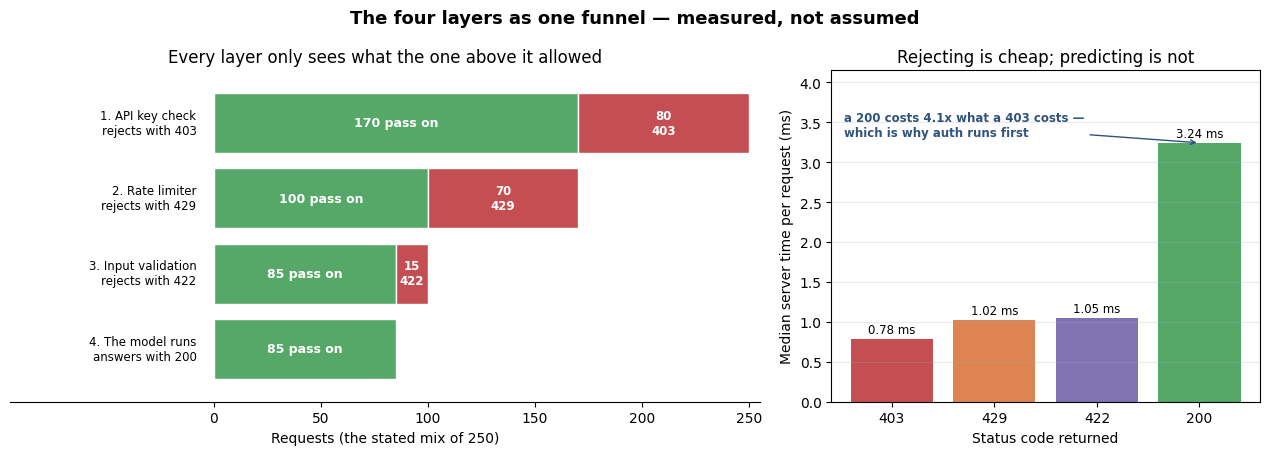

In [10]:
# WHAT: send a stated 250-request mix through the assembled secure API, record the
# real status code and response time of each, and draw the funnel they produce.
# WHY: the four tests above proved each layer works. This shows the ORDER working:
# a request has to survive every earlier, cheaper check before the model is allowed
# to spend CPU on it — and the counts and timings here are measured, not assumed.
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

rl_log.clear()   # start the 60-second window empty so the counts are reproducible

GOOD_KEY = {'X-API-Key': 'sk-prod-key-abc'}
BAD_PAYLOADS = [
    [99, 3.5, 1.4, 0.2],       # out of the physical range for sepal_length
    [5.1, 'x', 1.4, 0.2],      # a string where a float belongs
    [5.1, 3.5, 1.4],           # three features instead of four
]

# A STATED traffic mix, in repeating blocks of 50: 12 requests with no key at all,
# 4 with a wrong key, 5 with a valid key but malformed input, 29 ordinary ones.
block = ['no_key'] * 12 + ['bad_key'] * 4 + ['bad_input'] * 5 + ['good'] * 29
stream = block * 5                                   # 250 requests
valid_features = [5.1, 3.5, 1.4, 0.2]

results, latency_by_status = [], defaultdict(list)
for i, kind in enumerate(stream):
    if kind == 'no_key':
        headers, body = {}, {'features': valid_features}
    elif kind == 'bad_key':
        headers, body = {'X-API-Key': 'not-a-real-key'}, {'features': valid_features}
    elif kind == 'bad_input':
        headers, body = GOOD_KEY, {'features': BAD_PAYLOADS[i % len(BAD_PAYLOADS)]}
    else:
        headers, body = GOOD_KEY, {'features': valid_features}
    t0 = time.perf_counter()
    r = client.post('/predict', headers=headers, json=body)
    latency_by_status[r.status_code].append((time.perf_counter() - t0) * 1000)
    results.append(r.status_code)

counts = Counter(results)
n_total = len(results)
n_403, n_429, n_422, n_200 = (counts.get(c, 0) for c in (403, 429, 422, 200))

# Each layer only sees what the layer before it let through.
stages = [
    ('1. API key check\nrejects with 403',      n_total,               n_403, 403),
    ('2. Rate limiter\nrejects with 429',       n_total - n_403,       n_429, 429),
    ('3. Input validation\nrejects with 422',   n_total - n_403 - n_429, n_422, 422),
    ('4. The model runs\nanswers with 200',     n_200,                 0,     200),
]

print(f"{n_total} requests through the assembled API "
      f"(limit {PROD_RATE_LIMIT} per {PROD_WINDOW}s, one client IP)\n")
print(f"{'stage':>34}  {'entering':>8} {'rejected':>8} {'surviving':>9}")
for label, entering, rejected, code in stages:
    print(f"{label.replace(chr(10), ' '):>34}  {entering:8d} {rejected:8d} {entering - rejected:9d}")
print(f"\nStatus codes returned: " + ", ".join(f"{c}: {n}" for c, n in sorted(counts.items())))
# How much of the 429 block was traffic we actually wanted to serve?
good_429 = sum(1 for kind, code in zip(stream, results) if code == 429 and kind == 'good')
print(f"Of the {n_429} requests the rate limiter refused, {good_429} were ordinary valid traffic "
      f"({good_429 / n_429:.0%}) — the limit turns away users, not only attackers.")

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6),
                         gridspec_kw={'width_ratios': [1.75, 1]})

# --- Left: the funnel, measured -------------------------------------------
ax = axes[0]
for row, (label, entering, rejected, code) in enumerate(stages):
    y = len(stages) - 1 - row
    survived = entering - rejected
    ax.barh(y, survived, color='#55A868', edgecolor='white')
    if rejected:
        ax.barh(y, rejected, left=survived, color='#C44E52', edgecolor='white')
        ax.text(survived + rejected / 2, y, f'{rejected}\n{code}', ha='center', va='center',
                color='white', fontsize=8.5, fontweight='bold')
    ax.text(survived / 2, y, f'{survived} pass on', ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')
    ax.text(-8, y, label, ha='right', va='center', fontsize=8.5)
ax.set_xlim(-95, n_total * 1.02); ax.set_ylim(-0.7, len(stages) - 0.3)
ax.set_yticks([])
ax.set_xticks(range(0, n_total + 1, 50))   # no negative tick: there is no -50th request
ax.set_xlabel(f'Requests (the stated mix of {n_total})')
ax.set_title('Every layer only sees what the one above it allowed')
for s in ('top', 'right', 'left'):
    ax.spines[s].set_visible(False)

# --- Right: what each verdict cost the server ------------------------------
ax = axes[1]
codes = [c for c in (403, 429, 422, 200) if latency_by_status.get(c)]
meds = [float(np.median(latency_by_status[c])) for c in codes]
bar_colours = {403: '#C44E52', 429: '#DD8452', 422: '#8172B2', 200: '#55A868'}
bars = ax.bar([str(c) for c in codes], meds, color=[bar_colours[c] for c in codes])
ax.bar_label(bars, fmt='%.2f ms', fontsize=8.5, padding=2)
ax.set_ylabel('Median server time per request (ms)')
ax.set_xlabel('Status code returned')
ax.set_title('Rejecting is cheap; predicting is not')
ax.set_ylim(0, max(meds) * 1.28)
ax.annotate(f'a 200 costs {meds[-1] / meds[0]:.1f}x what a 403 costs —\n'
            f'which is why auth runs first',
            xy=(len(codes) - 1, meds[-1]), xytext=(0.03, 0.80), textcoords='axes fraction',
            fontsize=8.5, color='#31527d', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#31527d'))
ax.grid(alpha=0.25, axis='y')

fig.suptitle('The four layers as one funnel — measured, not assumed',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**🔍 Read the figure.** *Left:* every bar is the traffic **entering** one layer, green for what passes on and red for what that layer rejects, labelled with the status code it owns. The bars get shorter down the page because each layer only ever sees the survivors of the one above it. Two things are worth stopping on. First, the unauthenticated requests never reach the rate limiter at all — a flood only consumes your rate budget if it can authenticate. Second, the limiter's red block is mostly traffic you wanted to serve — the cell prints how many of those 429s were ordinary valid requests, and it is the large majority. At 100 requests per 60 seconds from one IP, a burst of genuine users is refused exactly like an attacker. A rate limit is a product decision about who you are willing to turn away, not a purely technical one.

*Right:* the measured median server time behind each verdict, from the same 250 requests. The 403 bar is the cheapest — the request is dropped before any work happens — and the 200 bar is the tallest, because only there does the model actually run. That ratio is the whole argument for the ordering: the cheapest check goes first so the expensive resource is the last thing an unwanted request can reach. (Millisecond values are from this machine and this in-process test client; the ordering is the durable part, not the absolute numbers.)

## Summary

Four security layers for an ML API:

| Layer | Tool | What it prevents |
|---|---|---|
| **Authentication** | API key (`X-API-Key`) or JWT (`Authorization: Bearer`) | Unauthorized callers |
| **Rate limiting** | In-memory sliding window, or cloud API Gateway | Abuse, DDoS, runaway costs |
| **Input validation** | `sanitize_input()` before calling the model | Crashes, garbage predictions, adversarial inputs |
| **HTTPS** | Cloud load balancer with TLS certificate | Credential interception, eavesdropping |

Apply all four. They are complementary, not alternatives to each other.

## Self-Check

1. **What is the difference between authentication and authorization?**
   *(Give a one-sentence definition of each. Can something be authenticated but not authorized?)*

2. **What does JWT stand for and what is in the payload?**
   *(Name the full term and at least two fields you would typically find in the payload.)*

3. **Why should you validate model inputs even if your API is authenticated?**
   *(Think about what an authenticated but malicious caller — or simply a buggy caller — could send.)*

## ⚠️ Where this breaks

- **The rate limiter is in-memory, so it dies at two replicas.** `{ip: [timestamps]}` lives in one process. Run three Gunicorn workers or three Kubernetes Pods and each keeps its own counter, so your "5 per 10 seconds" quietly becomes 15. A limit that must hold across replicas needs shared state (Redis) or an API gateway in front. This is the single most common way a hand-rolled limiter fails in production.
- **API keys are bearer credentials with no expiry.** Whoever holds the string is the caller. There is no revocation here, no rotation, no per-key scope, and the keys are hardcoded in the notebook. Real deployments put them in a secrets manager, rotate them, and scope them per client. JWTs improve on this by expiring — but a leaked token is still valid until it does.
- **Input validation stops crashes and probes; it does not stop ML-specific attacks.** The notebook says so and it is worth repeating as a limit: model inversion, membership inference and model extraction all use *perfectly valid* inputs. Defending against them means rate limits per identity, reduced output precision (returning a class instead of full probabilities), and monitoring for systematic querying — not stricter type checks.
- **The assumption that must hold:** TLS terminates somewhere before your app, and the network between that point and your service is genuinely trusted. Over plain HTTP, every layer above is theatre — the API key and the JWT are both readable by anyone on the path.
- **Everything is enforced in application code, which is the wrong layer for some of it.** Rate limiting, TLS, IP allow-lists and bot filtering are cheaper and more robust in an API gateway or load balancer, because they reject traffic before it reaches a process that loads a model. Keep in your app what needs application knowledge (input validation, per-model authorisation) and push the rest outward.
- **The cheaper alternative.** For an internal-only model, network-level isolation — a private subnet with no public route, plus mutual TLS between services — removes most of this attack surface without any of the code above. Authentication in the application is what you build when the service must be reachable from outside.

## 🔭 State of the field (2026)

All four layers above are still the minimum, and ShellTorch is still the right story to open with: nobody attacked a model, they attacked the service around it. Two things have widened that service since. First, **loading** the model artifact is itself an attack surface — a study accepted to IEEE S&P 2026 found that the major ML frameworks and model hubs address unsafe loading only partially, often by shifting responsibility to the user, and disclosed new zero-days that give arbitrary code execution on load; "where did this artifact come from" now belongs beside "who is calling this endpoint" (Digregorio et al., 2025). Second, when the thing behind the endpoint is a language model or a tool-using agent, the request body is no longer a float array you can range-check: untrusted text the system merely *reads* can become instructions it acts on (Greshake et al., 2023), and the 2026 response is layered red-teaming across the infrastructure, protocol, tool and model layers rather than a stricter input validator (Yang et al., 2026).

Learn the four layers here exactly as written — authentication, rate limiting, validation and TLS are what the official plan examines, and every newer defense is bolted onto them, not offered instead of them. Then add one question to the checklist for each new endpoint: which of these four layers can the request body walk straight through?

- Digregorio, G., et al. (2025). *On the (In)Security of Loading Machine Learning Models*. <https://arxiv.org/abs/2509.06703>
- Yang, Y., et al. (2026). *Securing the AI Agent: A Unified Framework for Multi-Layer Agent Red Teaming*. <https://arxiv.org/abs/2606.31227>

## 📚 References

1. Goodfellow, I. J., Shlens, J., & Szegedy, C. (2015). *Explaining and Harnessing Adversarial Examples*. ICLR. <https://arxiv.org/abs/1412.6572>
2. Papernot, N., McDaniel, P., Sinha, A., & Wellman, M. (2016). *Towards the Science of Security and Privacy in Machine Learning*. arXiv. <https://arxiv.org/abs/1611.03814>
3. Kumar, R. S. S., Nyström, M., Lambert, J., et al. (2020). *Adversarial Machine Learning — Industry Perspectives*. IEEE S&P Workshops. <https://arxiv.org/abs/2002.05646>
4. Greshake, K., Abdelnabi, S., Mishra, S., Endres, C., Holz, T., & Fritz, M. (2023). *Not what you've signed up for: Compromising Real-World LLM-Integrated Applications with Indirect Prompt Injection*. arXiv. <https://arxiv.org/abs/2302.12173>
5. Digregorio, G., Di Gennaro, M., Zanero, S., Longari, S., & Carminati, M. (2025). *On the (In)Security of Loading Machine Learning Models*. IEEE Symposium on Security and Privacy 2026. <https://arxiv.org/abs/2509.06703>
6. Yang, Y., Zheng, X., Wu, H., et al. (2026). *Securing the AI Agent: A Unified Framework for Multi-Layer Agent Red Teaming*. arXiv. <https://arxiv.org/abs/2606.31227>
